In [308]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [309]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
dataset = "high_grade_glioma"
# Tools: BAMixChecker, CrossCheckFingerprints, HYSYS, NGSCheckmate, Vireo

In [443]:
def all_samples_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    # Visualize ALL samples against ALL samples
    fig, ax = plt.subplots(figsize=(12, 12))
    extreme_point = max(
        abs(matrix_df.min().min()), abs(matrix_df.max().max())
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap)

    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_xticklabels(matrix_df.columns, rotation=45, ha="left")
    ax.set_yticklabels(matrix_df.index)
    ax.xaxis.set_label_position("top")
    ax.set_title(f"{tool} Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_all_samples_similarity_matrix.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_all_samples_similarity_matrix.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

In [441]:
def bulk_vs_singlecell_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    # Visualize bulk against single-cell samples
    sub_matrix = matrix_df[
        [col for col in matrix_df.columns if "single-cell" in col]
    ]
    sub_matrix = sub_matrix.loc[
        [idx for idx in sub_matrix.index if "bulk" in idx]
    ]

    extreme_point = max(
        abs(sub_matrix.min().min()), abs(sub_matrix.max().max())
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap)

    ax.set_xticks(np.arange(len(sub_matrix.columns)))
    ax.set_yticks(np.arange(len(sub_matrix.index)))
    ax.set_xticklabels(sub_matrix.columns, rotation=45, ha="left")
    ax.set_yticklabels(sub_matrix.index)
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Single-cell samples")
    ax.set_ylabel("Bulk samples")
    ax.set_title(f"{tool} Bulk vs Single-cell Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_bulk_vs_singlecell_similarity_matrix.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_bulk_vs_singlecell_similarity_matrix.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

# Vireo

In [386]:
vireo_matrix = pd.read_csv(DATA_PATH + f"vireo/{dataset}/similarity_matrix.csv", index_col=0)

In [387]:
vireo_matrix.columns = [col.replace(".bam", "") for col in vireo_matrix.columns]
vireo_matrix.index = pd.Index([idx.replace(".bam", "") for idx in vireo_matrix.index])

In [391]:
# Order rows and columns
ordered_samples = sorted(vireo_matrix.columns)
vireo_matrix = vireo_matrix.loc[ordered_samples, ordered_samples]

In [392]:
vireo_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,0.000000,0.112578,0.108454,0.110467,0.127652,0.104058,0.103935,0.104378,0.105350,0.104234,...,0.379126,0.377470,0.391542,0.377443,0.394204,0.393229,0.372062,0.393390,0.346097,0.393037
GSM7305243_bulk,0.112578,0.000000,0.107729,0.100709,0.139228,0.112894,0.113226,0.117423,0.112379,0.112008,...,0.372835,0.371601,0.385494,0.371504,0.387398,0.386560,0.366121,0.387931,0.341290,0.387840
GSM7305244_bulk,0.108454,0.107729,0.000000,0.102225,0.132817,0.108052,0.106365,0.109632,0.112394,0.109734,...,0.375738,0.374219,0.387962,0.373544,0.389867,0.389378,0.369913,0.389198,0.343543,0.389683
GSM7305245_bulk,0.110467,0.100709,0.102225,0.000000,0.133692,0.109315,0.108099,0.111124,0.114599,0.113374,...,0.374175,0.371167,0.386113,0.371822,0.387546,0.387292,0.367433,0.388264,0.339885,0.387439
GSM7305246_bulk,0.127652,0.139228,0.132817,0.133692,0.000000,0.127056,0.130576,0.129181,0.133358,0.131997,...,0.382341,0.379988,0.393892,0.380240,0.395606,0.395041,0.378628,0.396799,0.354048,0.396763


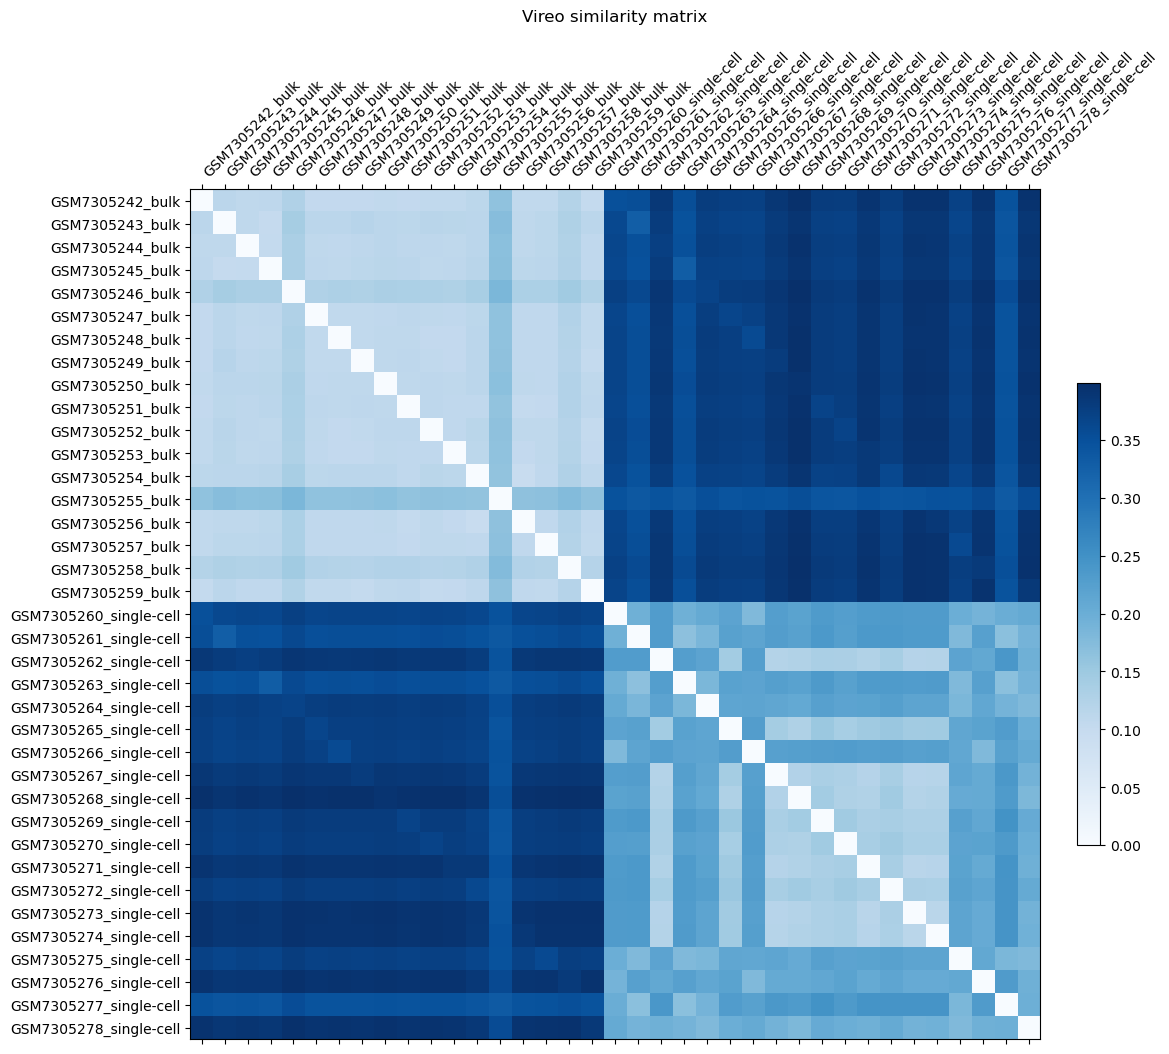

In [435]:
all_samples_matrix_viz(vireo_matrix, tool="Vireo", dataset=dataset, save_fig=True)

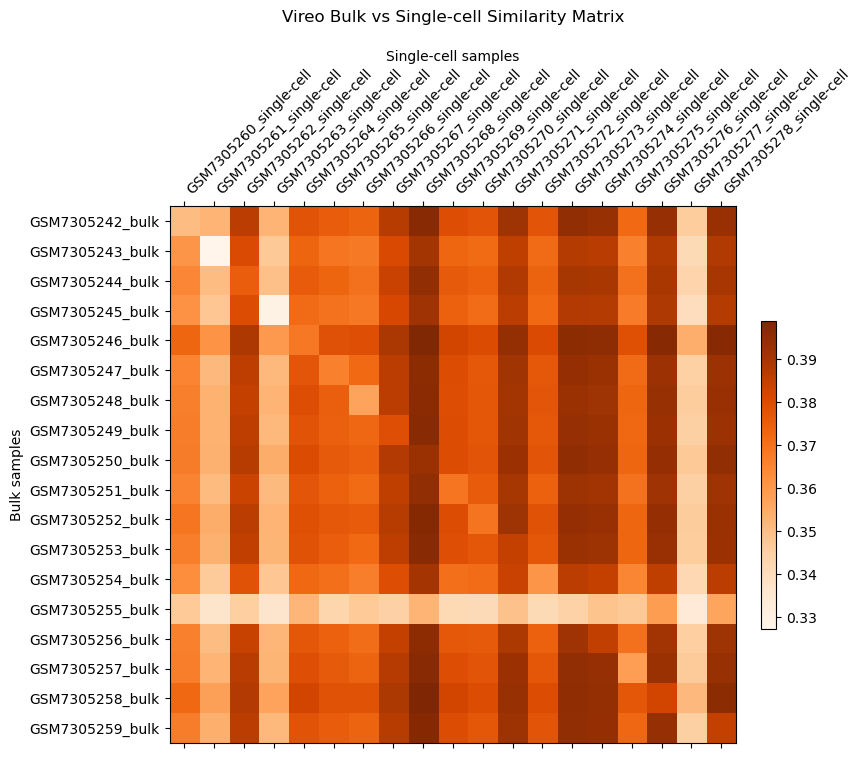

In [394]:
bulk_vs_singlecell_matrix_viz(vireo_matrix, tool="Vireo", dataset=dataset, save_fig=False)

# NGSCheckmate

In [395]:
ngscheckmate_df = pd.read_csv(DATA_PATH + f"ngscheckmate/{dataset}/output_all.txt", sep="\t", index_col=0, header=None)

In [396]:
ngscheckmate_dict = {
    x: 
    x.replace("_filtered_variants.vcf", "").replace("_bulk_chunk_ribo.bam", "")
    for x in list(set(ngscheckmate_df.index) | set(ngscheckmate_df[2]))
}
ngscheckmate_df.index = ngscheckmate_df.index.map(ngscheckmate_dict)
ngscheckmate_df[2] = ngscheckmate_df[2].map(ngscheckmate_dict)
ngscheckmate_df.columns = ["Matched", "Sample", "Binary", "Correlation"]

In [397]:
ngscheckmate_df.head()

,Matched,Sample,Binary,Correlation
0,,,,
GSM7305242_bulk,matched,GSM7305243_bulk,1.0,188.93
GSM7305242_bulk,matched,GSM7305244_bulk,1.0,194.23
GSM7305242_bulk,matched,GSM7305245_bulk,1.0,192.42
GSM7305242_bulk,matched,GSM7305246_bulk,1.0,202.75
GSM7305242_bulk,matched,GSM7305247_bulk,1.0,199.80


In [398]:
def long_df_to_matrix_ngscheckmate(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Correlation"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]/100
                matrix.at[x, y] = corr_value.values[0]/100

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [399]:
ngscheckmate_matrix = long_df_to_matrix_ngscheckmate(ngscheckmate_df)

In [400]:
ngscheckmate_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,NaN,1.8893,1.9423,1.9242,2.0275,1.9980,2.0275,2.0275,2.0200,1.9082,...,0.483,0.5835,0.3665,0.5318,0.4158,0.4107,0.7434,0.5815,1.1139,0.6044
GSM7305243_bulk,1.8893,NaN,1.8893,1.8893,1.8893,1.8893,1.8893,1.8893,1.8893,1.8893,...,0.483,0.5835,0.3665,0.5318,0.4158,0.4107,0.7434,0.5815,1.1139,0.6044
GSM7305244_bulk,1.9423,1.8893,NaN,1.9242,1.9423,1.9423,1.9423,1.9423,1.9423,1.9082,...,0.483,0.5835,0.3665,0.5318,0.4158,0.4107,0.7434,0.5815,1.1139,0.6044
GSM7305245_bulk,1.9242,1.8893,1.9242,NaN,1.9242,1.9242,1.9242,1.9242,1.9242,1.9082,...,0.483,0.5835,0.3665,0.5318,0.4158,0.4107,0.7434,0.5815,1.1139,0.6044
GSM7305246_bulk,2.0275,1.8893,1.9423,1.9242,NaN,1.9980,2.0444,2.0444,2.0200,1.9082,...,0.483,0.5835,0.3665,0.5318,0.4158,0.4107,0.7434,0.5815,1.1139,0.6044


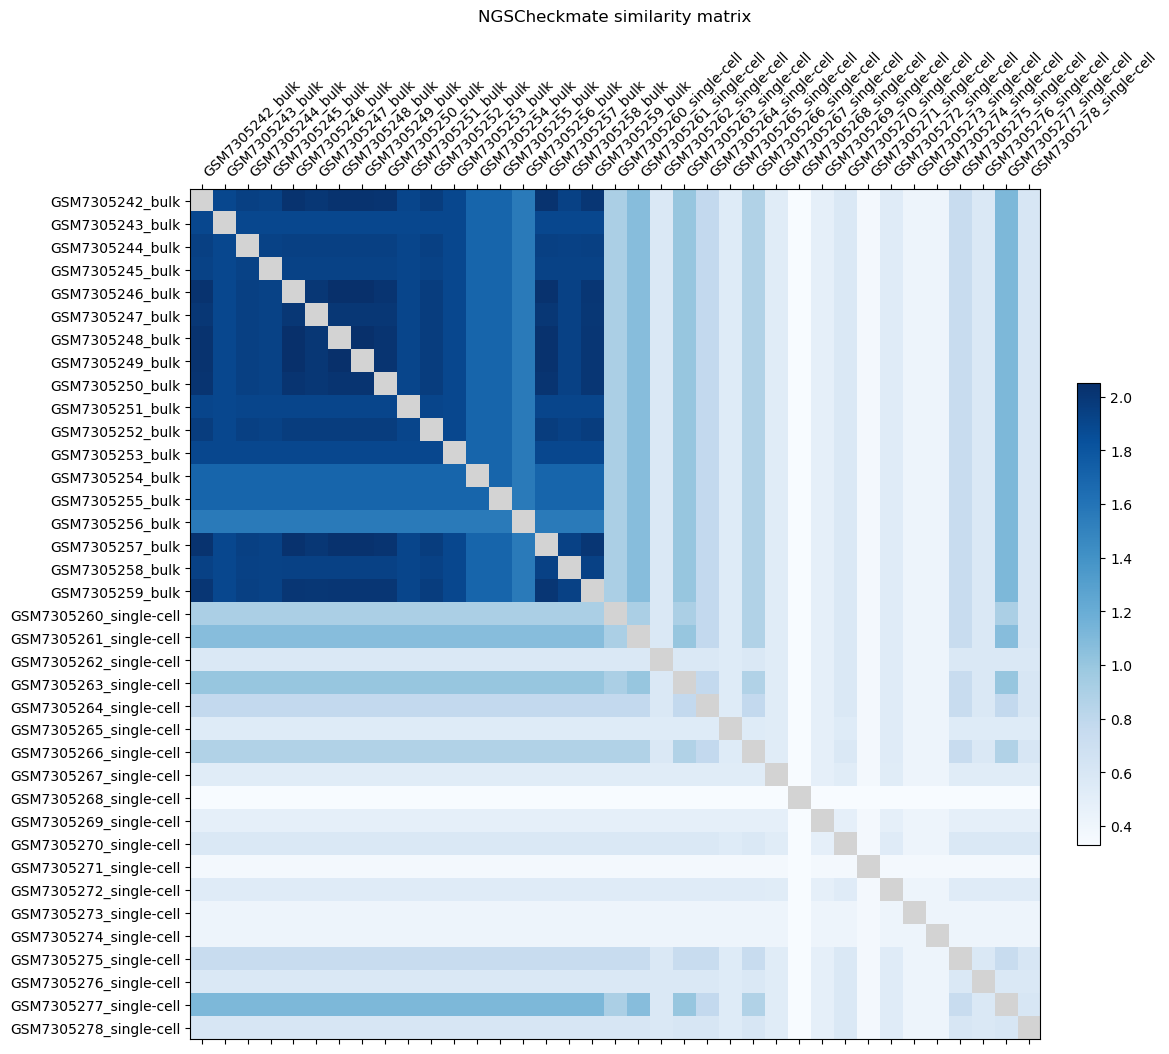

In [436]:
all_samples_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

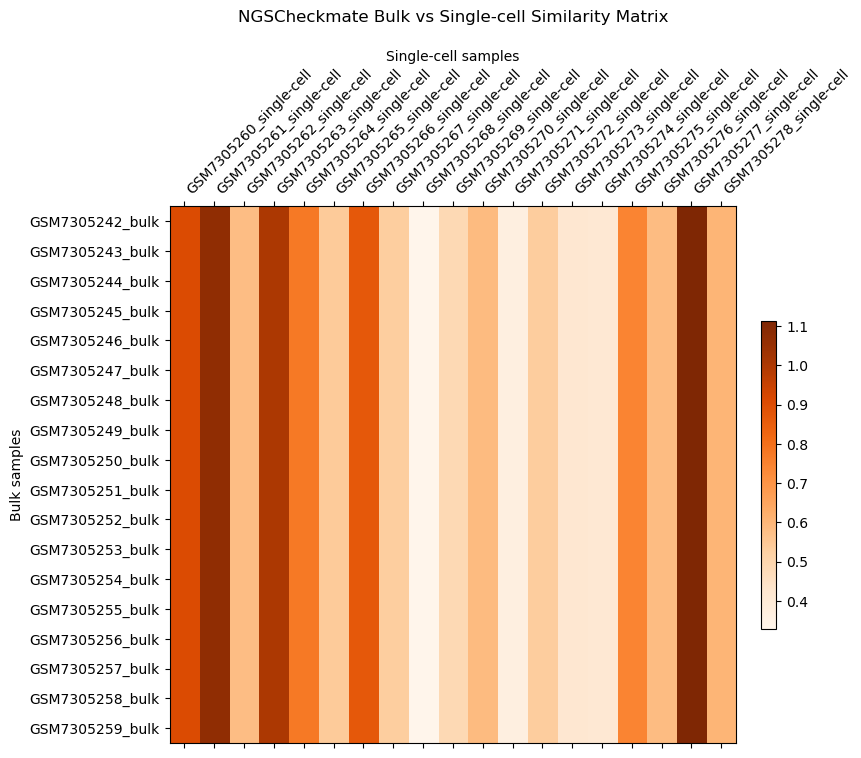

In [403]:
bulk_vs_singlecell_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

# HYSYS

In [446]:
hysys_df = pd.read_csv(DATA_PATH + f"hysys/{dataset}/concordance_output.txt", sep="\t", index_col=0, header=None)

In [447]:
hysys_dict = {
    x: 
    x.replace("_filtered_variants.snps", "").replace(f"{dataset}/", "")
    for x in list(set(hysys_df.index) | set(hysys_df[1]))
}
hysys_df.index = hysys_df.index.map(hysys_dict)
hysys_df[1] = hysys_df[1].map(hysys_dict)
hysys_df.columns = ["Sample", "Concordance", "Size"]

In [448]:
hysys_df.head()

,Sample,Concordance,Size
0,,,
GSM7305242_bulk,GSM7305242_bulk,1.000,8989
GSM7305242_bulk,GSM7305243_bulk,0.279,13878
GSM7305242_bulk,GSM7305244_bulk,0.323,13493
GSM7305242_bulk,GSM7305245_bulk,0.297,13288
GSM7305242_bulk,GSM7305246_bulk,0.345,13244


In [449]:
def long_df_to_matrix_hysys(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [450]:
hysys_matrix = long_df_to_matrix_hysys(hysys_df)

In [452]:
hysys_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,1.000,0.279,0.323,0.297,0.345,0.361,0.363,0.372,0.379,0.350,...,0.081,0.080,0.058,0.077,0.057,0.059,0.104,0.072,0.132,0.079
GSM7305243_bulk,0.279,1.000,0.277,0.288,0.257,0.287,0.287,0.280,0.292,0.266,...,0.073,0.073,0.052,0.067,0.052,0.056,0.097,0.063,0.124,0.070
GSM7305244_bulk,0.323,0.277,1.000,0.300,0.305,0.325,0.326,0.325,0.317,0.304,...,0.074,0.081,0.056,0.072,0.058,0.058,0.097,0.071,0.126,0.076
GSM7305245_bulk,0.297,0.288,0.300,1.000,0.269,0.294,0.302,0.302,0.289,0.270,...,0.072,0.077,0.053,0.067,0.055,0.055,0.096,0.063,0.131,0.074
GSM7305246_bulk,0.345,0.257,0.305,0.269,1.000,0.353,0.325,0.344,0.345,0.311,...,0.075,0.077,0.058,0.075,0.055,0.058,0.098,0.072,0.130,0.079


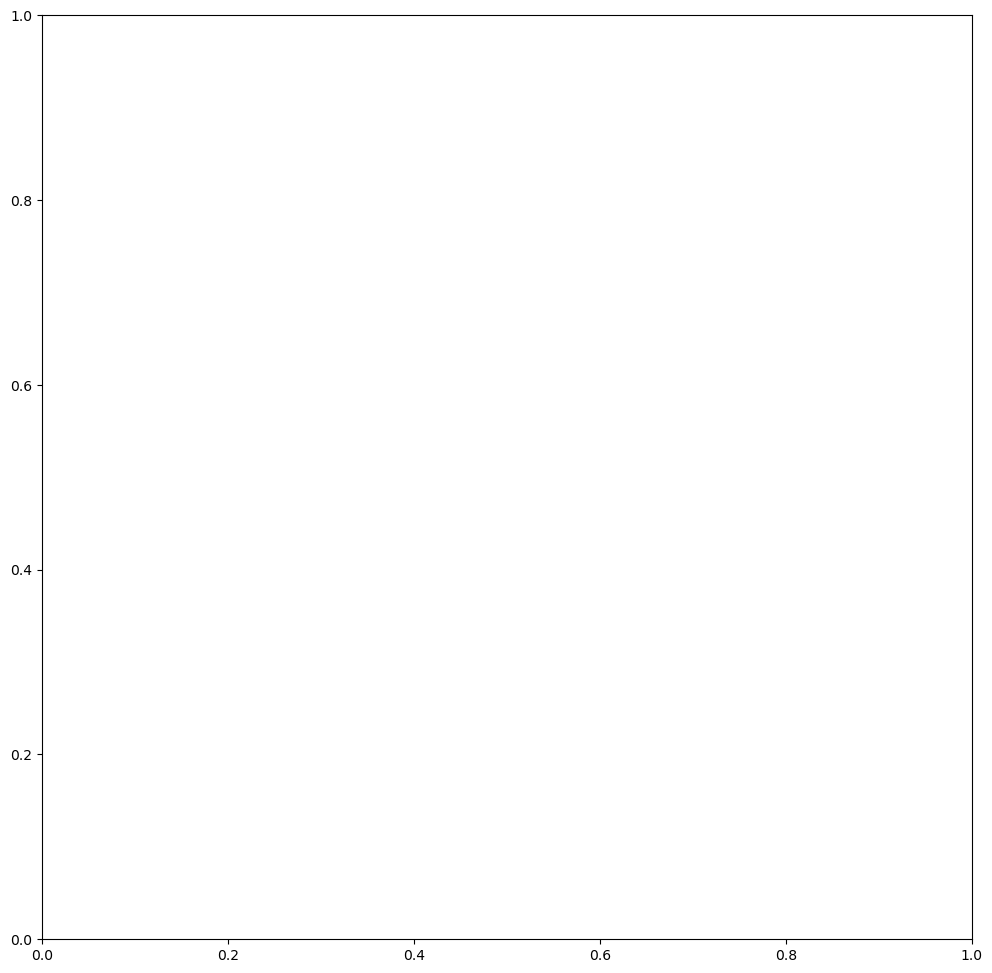

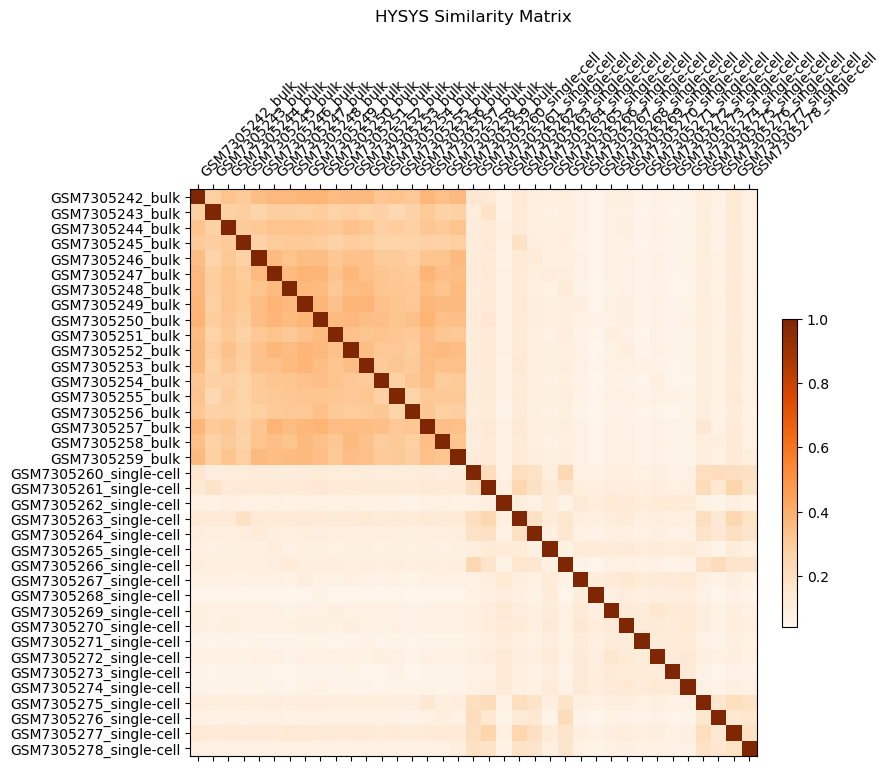

In [453]:
all_samples_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

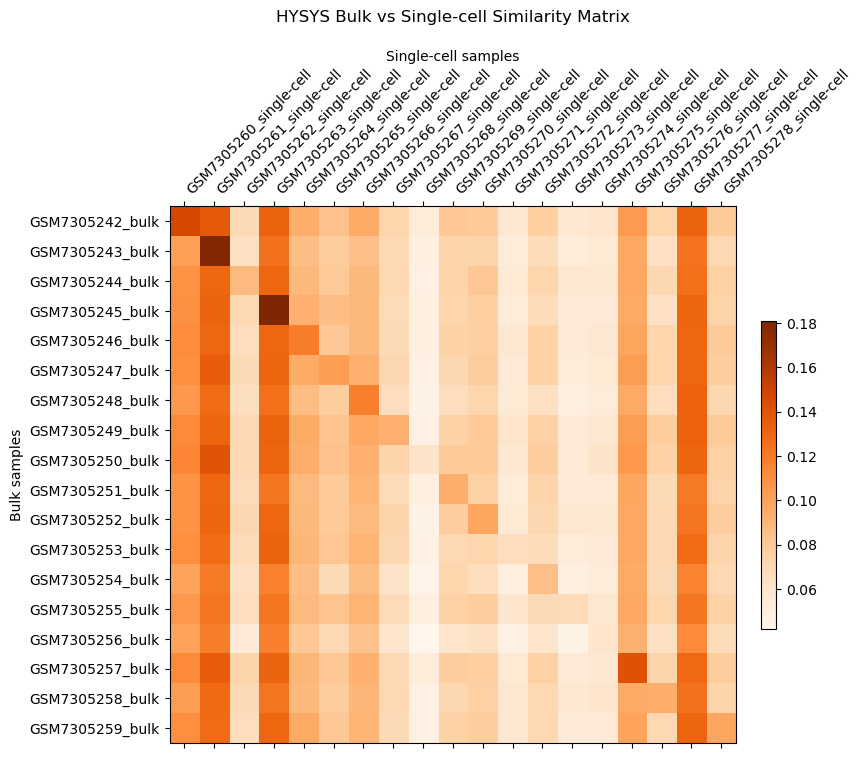

In [454]:
bulk_vs_singlecell_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

# CrossCheckFingerprints

In [413]:
fingerprints_df = pd.read_csv(DATA_PATH + f"fingerprints/{dataset}/crosscheck_metrics.txt", sep="\t", header=5)
fingerprints_df = fingerprints_df[["LEFT_SAMPLE", "RIGHT_SAMPLE", "LOD_SCORE", "RESULT"]]

In [414]:
fingerprints_dict = {
    x: 
    x.replace(".bam", "")
    for x in list(set(fingerprints_df["LEFT_SAMPLE"]) | set(fingerprints_df["RIGHT_SAMPLE"]))
}
fingerprints_df["LEFT_SAMPLE"] = fingerprints_df["LEFT_SAMPLE"].map(fingerprints_dict)
fingerprints_df["RIGHT_SAMPLE"] = fingerprints_df["RIGHT_SAMPLE"].map(fingerprints_dict)

In [415]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM7305242_bulk,GSM7305242_bulk,27.886222,EXPECTED_MATCH
1,GSM7305242_bulk,GSM7305251_bulk,-11.495902,EXPECTED_MISMATCH
2,GSM7305242_bulk,GSM7305248_bulk,-34.155106,EXPECTED_MISMATCH
3,GSM7305242_bulk,GSM7305257_bulk,-25.873654,EXPECTED_MISMATCH
4,GSM7305242_bulk,GSM7305269_single-cell,-0.525105,EXPECTED_MISMATCH


In [416]:
def long_df_to_matrix_fingerprints(df):
    matrix = pd.DataFrame()

    for x in df["LEFT_SAMPLE"].unique():
        for y in df["RIGHT_SAMPLE"].unique():
            corr_value = df.loc[(df["LEFT_SAMPLE"] == x) & (df["RIGHT_SAMPLE"] == y), "LOD_SCORE"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [417]:
fingerprints_matrix = long_df_to_matrix_fingerprints(fingerprints_df)

In [418]:
fingerprints_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,27.886222,-19.789367,-25.069287,-19.750742,-18.242129,-14.165462,-34.155106,-16.262880,-18.597160,-11.495902,...,-0.525105,-2.856929,-3.972132,-5.725580,-2.864075,0.810757,-11.921445,-4.899135,-3.579525,-0.692820
GSM7305243_bulk,-19.789367,32.942358,-13.203236,-25.358868,-21.764459,-29.476446,-19.931705,-23.055179,-22.241814,-16.719972,...,-3.500845,-2.959690,-4.256054,-5.040827,-0.146463,-1.295779,-5.673233,1.858642,0.846050,-1.398634
GSM7305244_bulk,-25.069287,-13.203236,30.570852,-26.946657,-22.550119,-25.186935,-20.088962,-24.285536,-28.209716,-14.349550,...,-5.496766,0.132937,-2.183155,-1.267359,-2.792159,-4.150335,-3.663884,-3.898671,0.242521,-0.857664
GSM7305245_bulk,-19.750742,-25.358868,-26.946657,34.968767,-17.167309,-6.780482,-30.881301,-20.374665,-35.290835,-6.818776,...,-3.867631,0.797383,-2.063953,2.357297,-2.447549,0.887695,-2.603380,2.059171,-0.392749,-0.915146
GSM7305246_bulk,-18.242129,-21.764459,-22.550119,-17.167309,29.295279,-10.505276,-27.878213,-12.181228,-30.281806,-24.533906,...,-0.710930,-2.419873,-3.463116,-0.267625,-1.856171,2.286028,-4.228407,0.195560,-2.818520,-4.193278


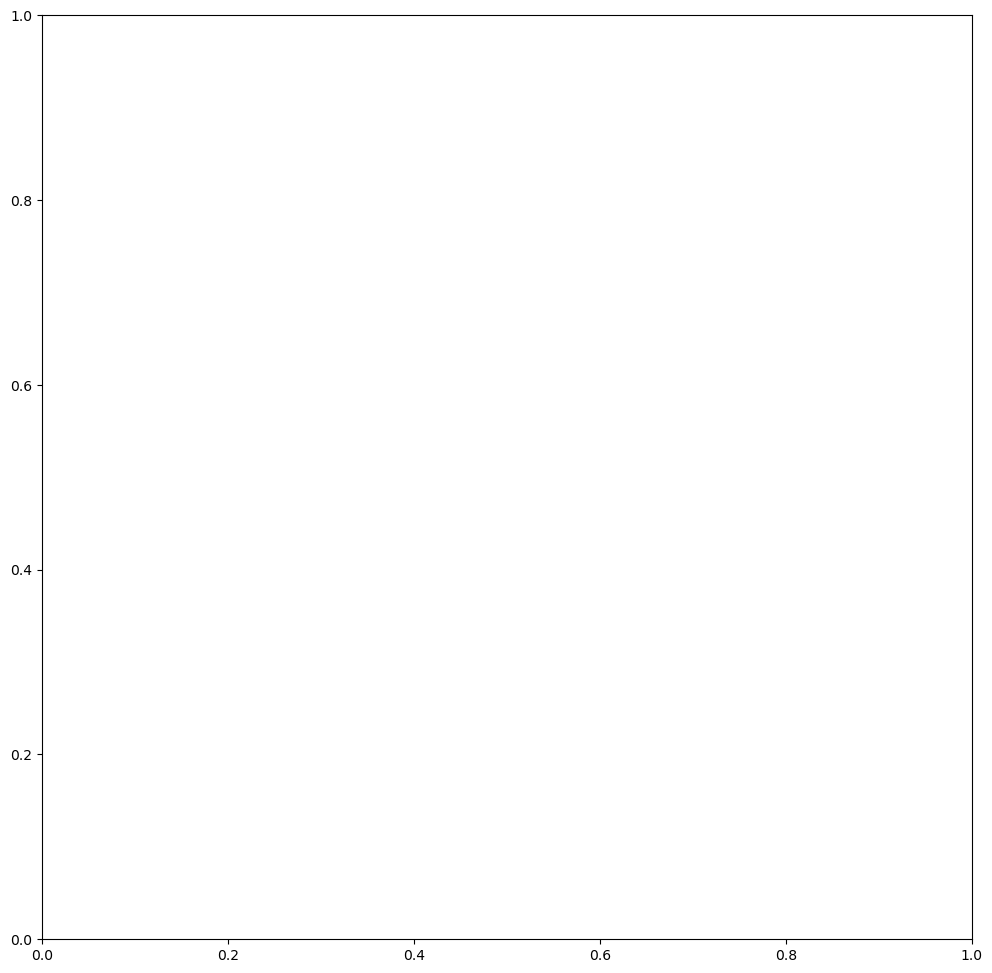

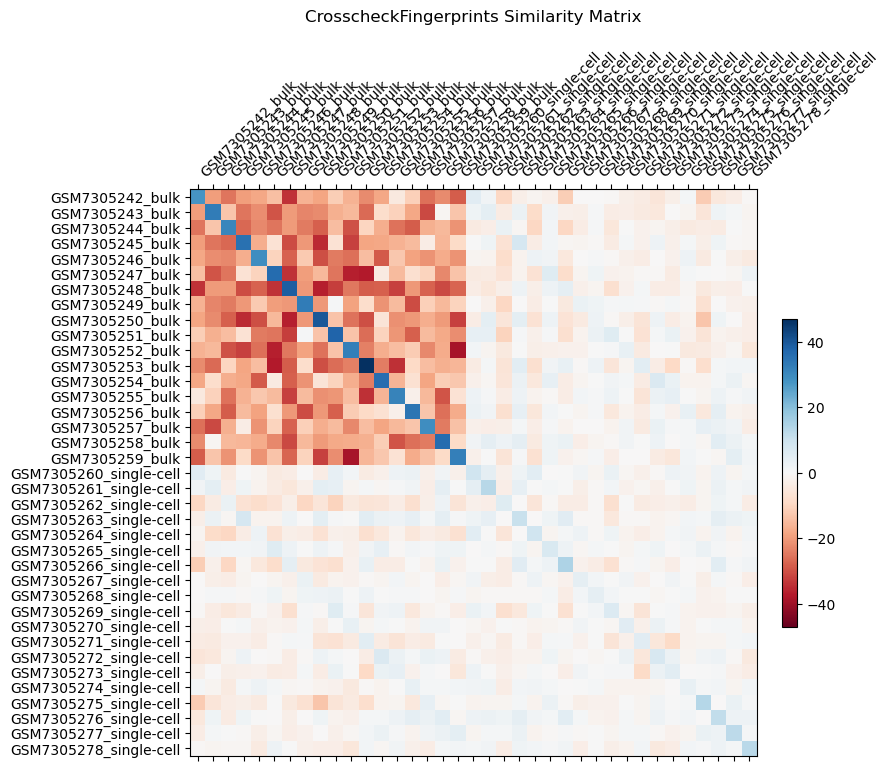

In [445]:
all_samples_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=False)

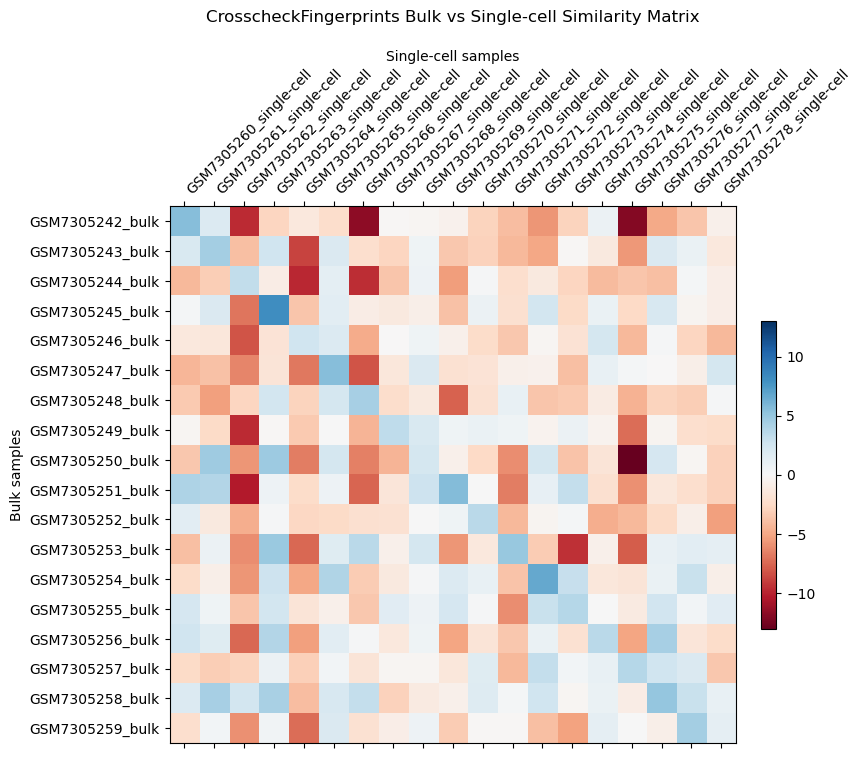

In [442]:
bulk_vs_singlecell_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

# BAMixChecker

In [425]:
bamixchecker_df = pd.read_csv(DATA_PATH + f"bamixchecker/{dataset}/BAMixChecker/Total_result.txt", sep="\t", index_col=0, header=None)
bamixchecker_df.columns = ["Sample", "Concordance Rate", "Conclusion"]

In [426]:
bamixchecker_dict = {
    x: 
    x.replace("_filtered_rg.bam", "") 
    for x in list(set(bamixchecker_df.index) | set(bamixchecker_df["Sample"]))
}
bamixchecker_df.index = bamixchecker_df.index.map(bamixchecker_dict)
bamixchecker_df["Sample"] = bamixchecker_df["Sample"].map(bamixchecker_dict)

In [427]:
bamixchecker_df.head()

,Sample,Concordance Rate,Conclusion
0,,,
GSM7305255_bulk,GSM7305258_bulk,0.0,Unmatched
GSM7305255_bulk,GSM7305253_bulk,0.0,Unmatched
GSM7305255_bulk,GSM7305250_bulk,0.0,Unmatched
GSM7305255_bulk,GSM7305257_bulk,0.0,Unmatched
GSM7305255_bulk,GSM7305242_bulk,0.0,Unmatched


In [428]:
def long_df_to_matrix_bamixchecker(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance Rate"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]
                matrix.at[x, y] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [429]:
bamixchecker_matrix = long_df_to_matrix_bamixchecker(bamixchecker_df)

In [439]:
bamixchecker_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305243_bulk,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305244_bulk,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305245_bulk,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305246_bulk,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


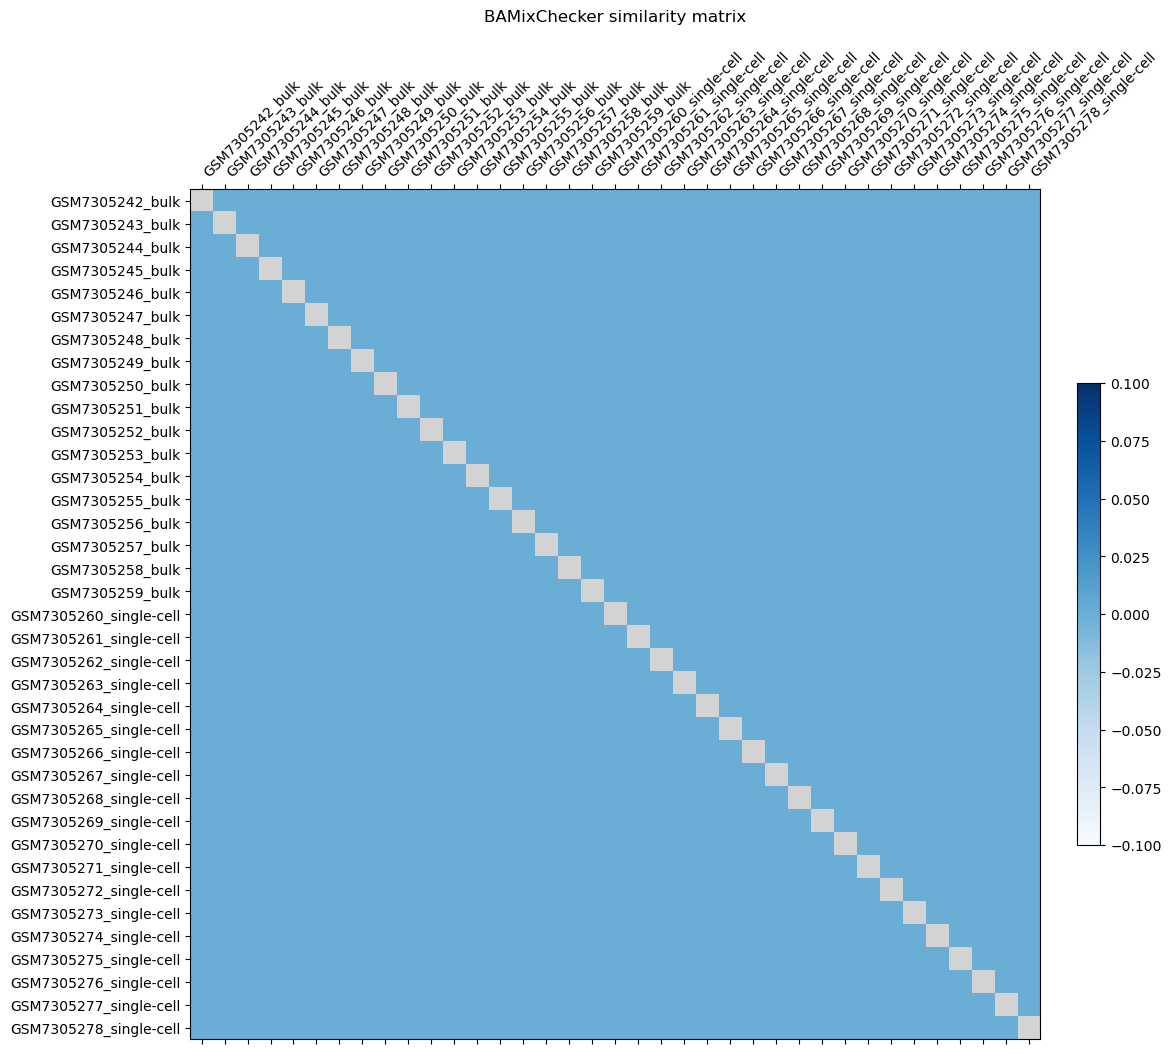

In [440]:
all_samples_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

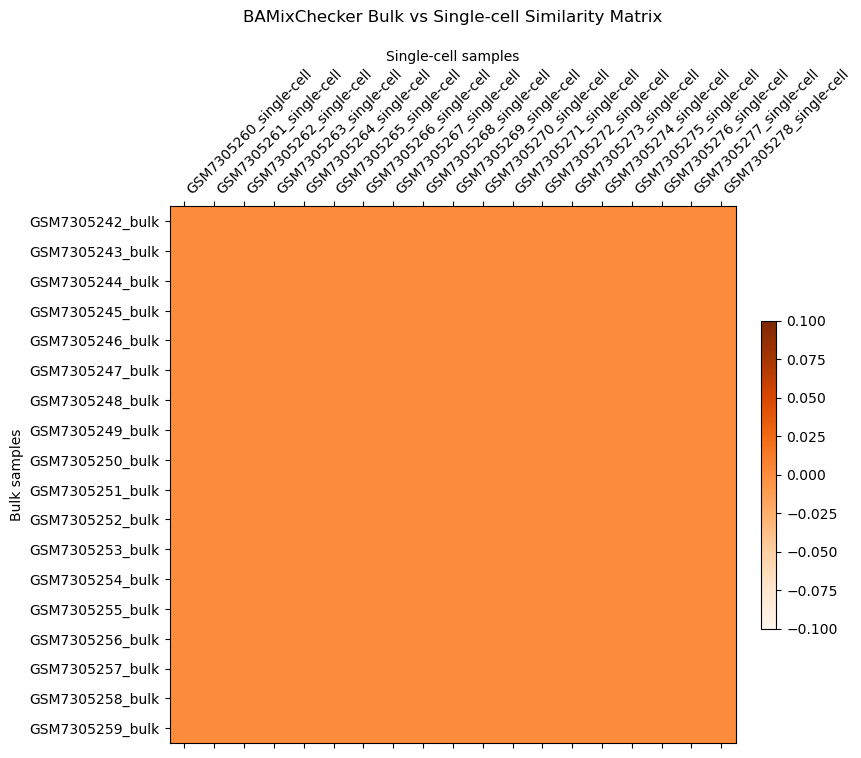

In [432]:
bulk_vs_singlecell_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

# Tool comparison

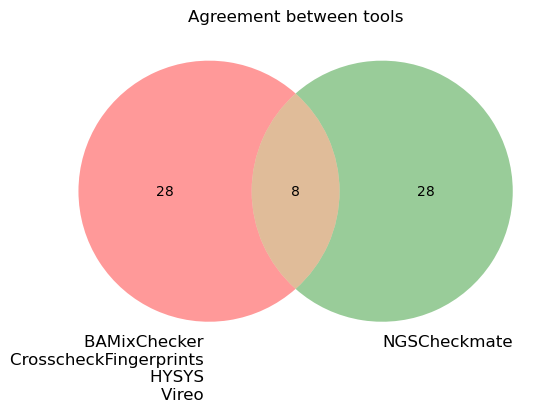

In [ ]:
venn2(subsets=(28, 28, 8), set_labels=('BAMixChecker \nCrosscheckFingerprints \nHYSYS \nVireo ', 'NGSCheckmate'))
plt.title("Agreement between tools")
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.png", bbox_inches="tight", dpi=300)
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.pdf", bbox_inches="tight", dpi=300